# Design optimization of coronagraph for  2D geometry
This notebook shows an example of coronagraph design optimization for 2D geometry with the corono package.

Author: Mamadou N'Diaye <mamadou.ndiaye@oca.eu> (https://github.com/astromam)

License: MIT license

## Initialization
This section lists all the required packages to run the notebook.

In [1]:
import numpy as np
import pylab as pl
import time
import os
from pathlib import Path

from astropy.io import fits
import corono as coro

## Parameters
This section lists all the parameters for the coronagraph and the optimization problem.

In [2]:
# coronagraph, problem, and solver types 
corono_name  = 'APLC' # 'SP' or 'APLC'
pupil_name   = 'sbr' # 'vlt' or 'sbr' or 'lvr'
problem_name = 'MaxContrastL1' # 'MaxTau' # ,'MaxContrastLinf' # 'MaxContrastL1' #
solver       = 'stdgrb' #,'stdgrb' #  'gurobipy', 'scipy.linprog'

# keywords for solver
slvLogToConsole = 0
slvCrossover    = 0
slvMethod       = 2
allLogToConsole = 0

# additional constraints and their parameters
MinIsland         = False
Binarity          = False
FirstDerGlobalLim = 100.
BinarityReg       = 0.1

# Pixel centering of the pupils and image for optimization
CtrBtwnPix  = True
CtrBtwnPix2 = True
Pupil2dSym  = True

Sampling

In [3]:
nPup = 50
nFPM = 50
Fmax2d = 22.5
nImg2d = 45

Optical system

In [4]:
# spectral bandwidth
bw   = 0.1
nlam = 5

# mask radius in lam0/D units
rMask = 4.0

Optimization

In [5]:
# dark zone bounds (inner and outer edges) in lam0/D unit
rho0 =  5.0
rho1 = 10.0

# contrast in the dark region
cDarkHole = 7.0

# tau (integrated Pupil transmission)
tau   = 0.4



File reading for Pupil and Lyot stop

In [6]:
fdir = Path('../../data/2D/pupils/').resolve()
if pupil_name == 'lvr':
    fname_pup = 'ATLAST_Aperture_nPup={0}.fits'.format(nPup,)
    fname_lys = 'ATLAST_LyotStop_nPup={0}.fits'.format(nPup,)
else:
    fname_pup = 'pupil={0}_nPup={1}.fits'.format(pupil_name, nPup,)
    fname_lys = 'pupil={0}_nPup={1}.fits'.format(pupil_name, nPup,)

fpath_pup = fdir / fname_pup
fpath_lys = fdir / fname_lys
Pupil2d    = fits.getdata(fpath_pup)
LyotStop2d = fits.getdata(fpath_lys)

Dictionary

In [7]:
# Test on solver type
if solver != 'gurobipy' and solver != 'stdgrb':
    solver = 'scipy'

# Definition of a dictionary of parameters 
params = coro.to_dict(nPup=nPup, Fmax2d = Fmax2d, nImg2d=nImg2d, nFPM = nFPM,
                 rho0=rho0, rho1=rho1, cDarkHole=cDarkHole, tau=tau, 
                 CtrBtwnPix=CtrBtwnPix, CtrBtwnPix2 = CtrBtwnPix2,
                 nlam=nlam, bw=bw,
                 Pupil2d = Pupil2d, LyotStop2d = LyotStop2d,
                 Pupil2dSym = Pupil2dSym, rMask=rMask,
                 problem_name = problem_name, 
                 solver = solver, 
                 corono_name = corono_name, pupil_name = pupil_name,
                 slvLogToConsole = slvLogToConsole,
                 slvCrossover = slvCrossover, slvMethod = slvMethod,
                 allLogToConsole = allLogToConsole,
                 MinIsland = MinIsland, FirstDerGlobalLim = FirstDerGlobalLim,
                 Binarity = Binarity, BinarityReg = BinarityReg)


### Plot parameters

In [8]:
# spectral sampling
nlambis = 11

# image sampling
nImg2dbis = 500

# maximum spatial frequency in the image
Fmax2dbis = 50

## Coronagraph definition
Definition of an object from the coronagraph class in design module.

In [9]:
if corono_name == 'SP':
    # Shaped Pupil
    corono0 = coro.design.SP2d(**params)
elif corono_name == 'APLC':
    # Apodized Pupil Lyot Coronagraph
    corono0 = coro.design.APLC2d(**params)
else:
    raise NameError('{0}: Not an existing coronagraph!'.format(corono_name))

## Problem definition
Definition of an object from the optim_1d class in optim_1d module.

In [10]:
if problem_name == 'MaxTau':
    # Maximization of the integrated amplitude transmission of the apodizer
    problem1 = coro.optim_2d.MaxTau(corono=corono0, **params)
elif problem_name == 'MaxContrastL1':
    # Maximization of the contrast under L1-norm
    problem1 = coro.optim_2d.MaxContrast(corono=corono0, Lnorm='L1',**params)
elif problem_name == 'MaxContrastLinf':
    # Maximization of the contrast under L-infinite norm
    problem1 = coro.optim_2d.MaxContrast(corono=corono0, Lnorm='Linf',**params)
else:
    raise NameError('{0}: Not an existing optimization problem!'.format(problem_name))

## Problem solving

In [11]:
# Problem solving 
t0 = time.time()
Apod1 = problem1.solve_model()
t1 = time.time()
print('optimization time             : {0:.2f}s'.format(t1-t0))

#Generation of full apodizer for quarter pupil optimization
Apod1_2d = np.reshape(Apod1, (corono0.nPup, corono0.nPup))

if Pupil2dSym == True:
        Apod1_2dtmp =  Apod1_2d[corono0.nPup//2:, corono0.nPup//2:]
        Apod1_2d[:corono0.nPup//2, corono0.nPup//2:] = np.flip(Apod1_2dtmp, axis=0)
        Apod1_2d[:, :corono0.nPup//2]          = np.flip(Apod1_2d[:, corono0.nPup//2:], axis=1)

optimization time             : 3.18s


## Plot display of the amplitude transmissions of the optical system elements

### Aperture

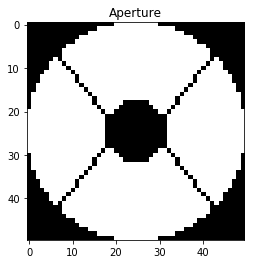

In [12]:
pl.figure(4)
pl.clf()
pl.imshow(corono0.Pupil2d, cmap = 'Greys_r')
pl.title('Aperture')
pl.show()

### Lyot Stop

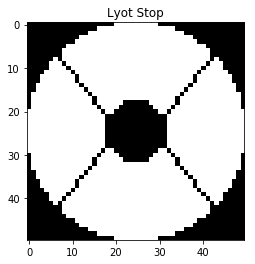

In [13]:
pl.figure(5)
pl.clf()
pl.imshow(corono0.LyotStop2d, cmap = 'Greys_r')
pl.title('Lyot Stop')
pl.show()

### Apodizer

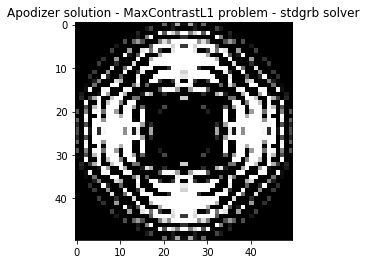

In [14]:
pl.figure(6)
pl.clf()
pl.imshow(Apod1_2d*corono0.Pupil2d, cmap = 'Greys_r')
pl.title('Apodizer solution - {0} problem - {1} solver'.format(problem_name, solver))
pl.show()

## Computation of the direct and coronagraphic images

Update of the params dictionary for plot purpose

In [15]:
params2    = coro.update_params(params, nlam=nlambis, Fmax2d = Fmax2dbis, nImg2d = nImg2dbis) 

Definition of the corono.design with updated parameters

In [16]:
if corono_name == 'SP':
    # Shaped Pupil
    corono0 = coro.design.SP2d(**params2)
elif corono_name == 'APLC':
    # Apodized Pupil Lyot Coronagraph
    corono0 = coro.design.APLC2d(**params2)
else:
    raise NameError('{0}: Not an existing coronagraph!'.format(corono_name))

Computation of the broadband light images

In [17]:
# broadband light image computation with and without coronagraph mask
poly_direct_image1 = corono0.compute_direct_intensity_2d(Apod1_2d)
poly_corono_image1 = corono0.compute_corono_intensity_2d(Apod1_2d)

# image normalization
peak_norm_poly = 1./poly_direct_image1.max()
poly_direct_image1 *= peak_norm_poly
poly_corono_image1 *= peak_norm_poly

Computation of the monochromatic light images

In [18]:
# monochromatic light image computation with and without coronagraph mask
mono_direct_image1 = corono0.compute_direct_intensity_2d(Apod1_2d, poly=False)
mono_corono_image1 = corono0.compute_corono_intensity_2d(Apod1_2d, poly=False)

# image normalization
peak_norm_mono = 1./mono_direct_image1[(corono0.nlam+1)//2].max()
mono_direct_image1 *= peak_norm_mono
mono_corono_image1 *= peak_norm_mono

## Plot display of the images

Direct image

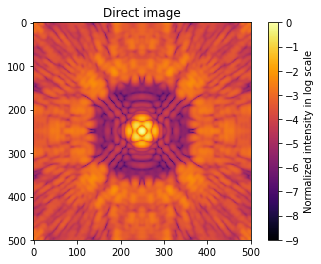

In [19]:
pl.figure(10)
pl.clf()
pl.imshow(np.log10(poly_direct_image1), cmap = 'inferno', vmin=-9, vmax=0.)
pl.title('Direct image')
cbar = pl.colorbar()
cbar.set_label('Normalized intensity in log scale')
pl.show()

Coronagraphic image

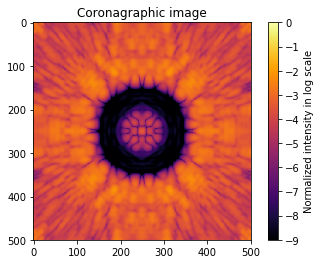

In [20]:
pl.figure(11)
pl.clf()
pl.imshow(np.log10(poly_corono_image1), cmap = 'inferno', vmin=-9, vmax=0.)
pl.title('Coronagraphic image')
cbar = pl.colorbar()
cbar.set_label('Normalized intensity in log scale')
pl.show()

### Broadband light

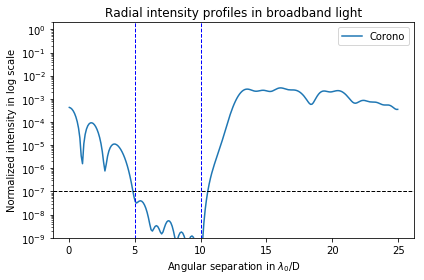

In [21]:
xi2d = corono0.xi2d
if nImg2dbis%2 == 0:
    xi2d = corono0.xi2d_ctr

nImg2d = corono0.params['nImg2d']

pl.figure(8)
pl.clf()
pl.title('Radial intensity profiles in broadband light')
pl.semilogy(xi2d,poly_corono_image1[nImg2dbis//2,nImg2dbis//2:],
                label='Corono')   
pl.axvline(x=corono0.rho0, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axvline(x=corono0.rho1, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axhline(10**(-cDarkHole), xmin=corono0.xi.min(), xmax=corono0.xi.max(), linewidth=1, color='k', linestyle='--')
pl.xlabel(r'Angular separation in $\lambda_0$/D')
pl.ylabel('Normalized intensity in log scale')
pl.ylim(1e-9, 2e0)
pl.legend()
pl.tight_layout()
pl.show()

### Monochromatic light

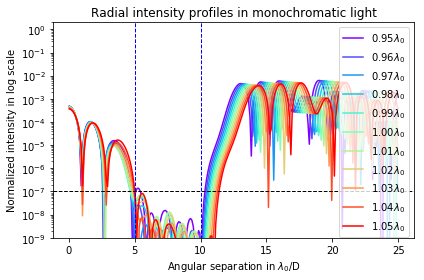

In [22]:
values = range(nlambis)
colors = pl.cm.rainbow(np.linspace(0,1,nlambis))

pl.figure(21)
pl.clf()
pl.title('Radial intensity profiles in monochromatic light')
for i in range(corono0.nlam):
    pl.semilogy(xi2d,mono_corono_image1[i, nImg2dbis//2,nImg2dbis//2:], '-',
                    label=r'{0:.2f}$\lambda_0$'.format(corono0.lam_t[i]),  
                    color = colors[i])
pl.axvline(x=corono0.rho0, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axvline(x=corono0.rho1, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axhline(10**(-cDarkHole), xmin=corono0.xi.min(), xmax=corono0.xi.max(), linewidth=1, color='k', linestyle='--')
pl.xlabel(r'Angular separation in $\lambda_0$/D')
pl.ylabel('Normalized intensity in log scale')
pl.ylim(1e-9, 2e0)
pl.legend()
pl.tight_layout()
pl.show()